In [1]:
import OptimalBattery.simulate as sim
import OptimalBattery.util as ut
import OptimalBattery.plot as plot
import OptimalBattery.evaluate as ev
import HierarchBayesParcel.spatial as spatial
import HierarchBayesParcel.arrangements as ar
import torch as pt
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigh
from scipy.stats import pearsonr
import seaborn as sns
import os
import pandas as pd



# start with some U_true and make it arrange.logpi

In [2]:
height = 30
width = 30
K_main = 5
K_subparcels = 5
K_total = 25

grid = spatial.SpatialGrid(height, width)
arrangeT = ar.ArrangeIndependent(K=25, P=grid.P)
centroids = [(0, 0), (29, 0), (0, 29), (29, 29), (14, 14)]


In [3]:
custom_cmap = plot.create_custom_colormap(['red', 'blue', 'green', 'yellow', 'purple'],K_subparcels=5)

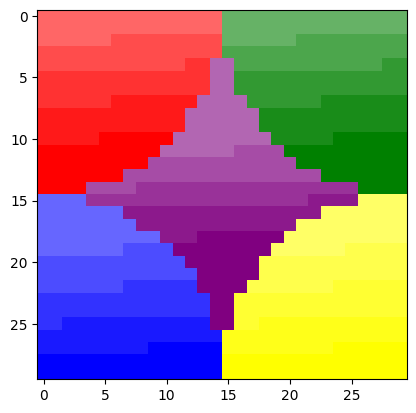

In [4]:
U_true_25 = sim.make_U_spatial(grid, centroids, K_main, K_subparcels)
U_true_25 = pt.tensor(U_true_25, dtype=pt.float32)
arrangeT.logpi = pt.log(U_true_25)

parcel_labels_plot = U_true_25.argmax(dim=0).numpy()
parcel_labels_plot = parcel_labels_plot.reshape((height, width))
plt.imshow(parcel_labels_plot, cmap=custom_cmap)

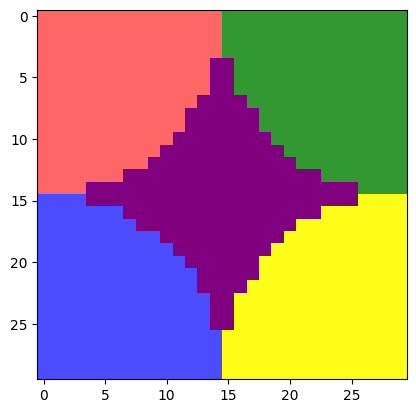

In [5]:
U_true_5 = sim.make_U_spatial(grid, centroids, K_main, 1)
U_true_5 = pt.tensor(U_true_5, dtype=pt.float32)

parcel_labels_plot = U_true_5.argmax(dim=0).numpy()
parcel_labels_plot = parcel_labels_plot.reshape((height, width))
plt.imshow(parcel_labels_plot, cmap=custom_cmap)

# Make Vs based on a task covariance + parcel covariance

Covarince across parcels R

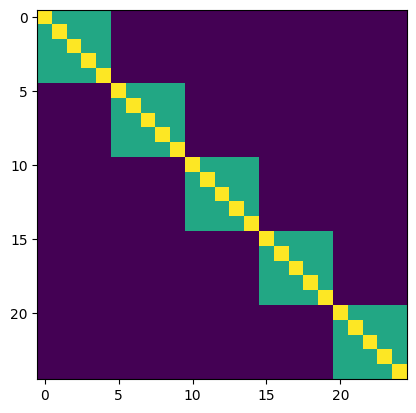

In [6]:
R= sim.custom_R(K_total =25, group_size=5, base_parcel_correlation=0.5, sub_parcel_extra_correlation=0.3)
plt.imshow(R)


covariance across tasks G

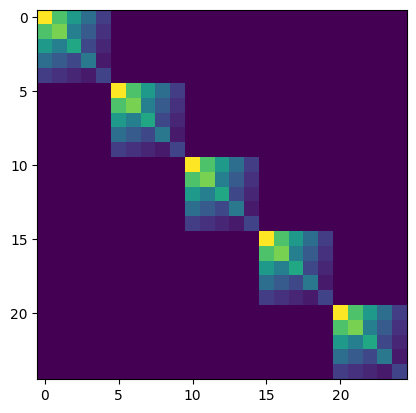

In [7]:
G = sim.custom_G(n_tasks=25, n_groups=5, group_size=5, target_corr=0.9, variance_factors=[1.0, 0.8,0.6, 0.4, 0.2])
plt.imshow(G)

make Vs

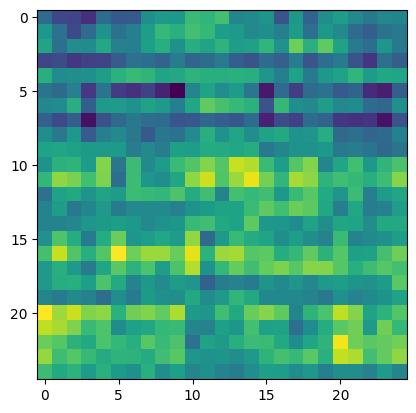

In [8]:
Vs= sim.random_matrix_normal(G=G, R=R, make_exact=True, rng=np.random.default_rng(15))
Vs = pt.tensor(Vs, dtype=pt.float32)

plt.imshow(Vs)


check covariance across rows and columns

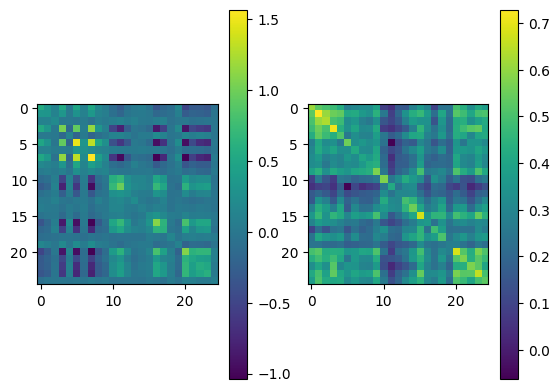

In [9]:
plt.subplot(1, 2, 1)
plt.imshow(Vs @ Vs.T, cmap='viridis')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(Vs.T @ Vs, cmap='viridis')
plt.colorbar()
plt.show()


# make true data

In [10]:
Y_true = Vs @ U_true_25
Y_true_noisy= Y_true + pt.randn_like(Y_true) * 0.0

G matrix used for eigenmetrics

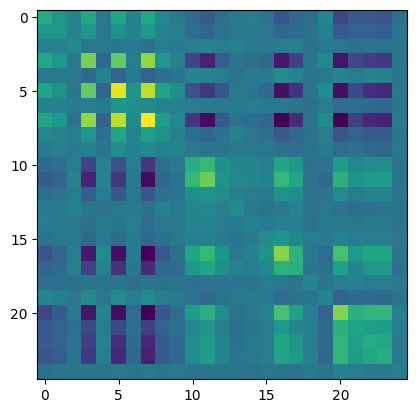

In [11]:
G_lib  = Y_true_noisy @ Y_true_noisy.T
G_lib = np.array(G_lib)
plt.imshow(G_lib)

# make test data

only use the last 5 tasks (really activate region of interest) and Vs of the last 5 parcels only 

In [12]:
Y_test = Y_true[20:, :]
Y_test_noisy = Y_test + pt.randn_like(Y_test) * 0.0
vtest = Vs[20:, 20:]


# Build combination dataframe

In [13]:
offsets = [1e-8,1e-6,1e-4,1e-2,1,1e2,1e4,1e6,1e8]
D = ut.build_combinations(G_lib, strategy='random',offs = offsets,n_iter=1000,n_tasks=8,seed=409)



building0


In [14]:
D = ev.evaluate_combinations_simulation(D,Y_true_noisy, Vs, Y_test_noisy, vtest, U_true_25,parcels_to_evaluate=[20,21,22,23,24])

C:\Users\barafat\Documents\GitHub\OptimalBattery\evaluate.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ytest = pt.tensor(ytest,dtype=pt.float32)
C:\Users\barafat\Documents\GitHub\OptimalBattery\evaluate.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  vtest = pt.tensor(vtest,dtype=pt.float32)


Processing combination: 0
Processing combination: 100
Processing combination: 200
Processing combination: 300
Processing combination: 400
Processing combination: 500
Processing combination: 600
Processing combination: 700
Processing combination: 800
Processing combination: 900


In [19]:
ev.evaluate_single_combination(Y_true_noisy, Vs, Y_test_noisy, vtest, U_true[20:, :],(11, 22, 11, 22, 11, 22, 11, 22))

165.44148


C:\Users\barafat\Documents\GitHub\OptimalBattery\evaluate.py:60: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ytest = pt.tensor(ytest,dtype=pt.float32)
C:\Users\barafat\Documents\GitHub\OptimalBattery\evaluate.py:61: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  vtest = pt.tensor(vtest,dtype=pt.float32)


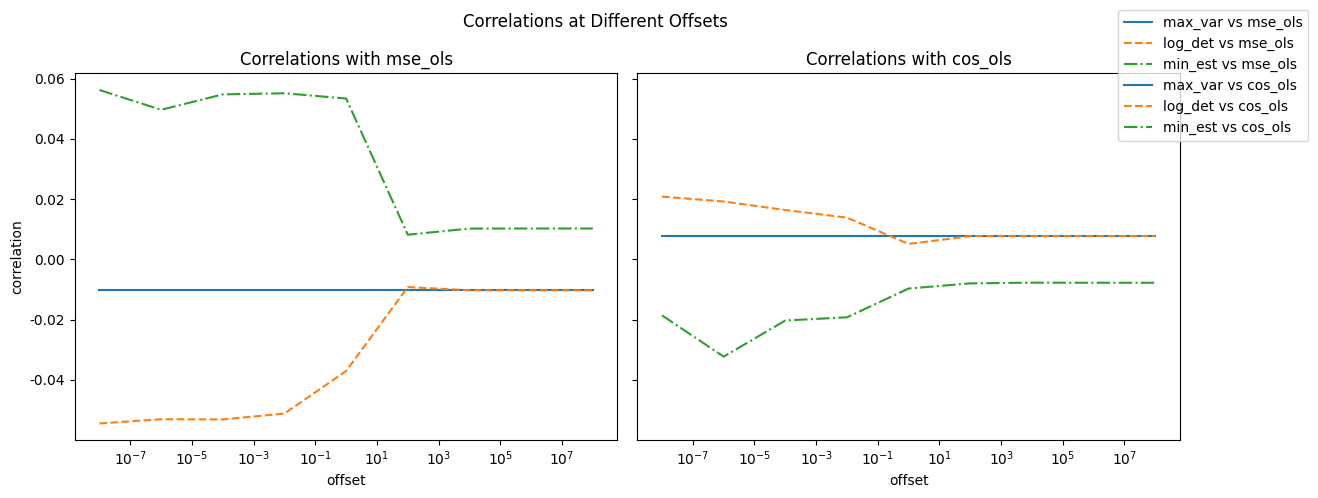

In [20]:
plot.plot_correlations(D,['max_var','log_det','min_est'],['mse_ols','cos_ols'])